In [1]:
import data_generator as data
from MMD_test import mmd_rbf_unbiased, mmd_permutation_test
import seaborn as sns
import matplotlib.pyplot as plt
import pickle 
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import data_generator_update as data2
from acceptance_loop import AcceptanceLoop
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from Evaluation import Metric, AUC, BS, PAUC, ABR, Evaluation, bayesianMetric
from reject_inference import RejectInference, BiasAwareSelfLearning
import random
from sklearn.preprocessing import StandardScaler
from Tabpfn import train_tabpfn
from MMD_test import mmd_rbf_unbiased, mmd_permutation_test


In [10]:
import importlib
import data_generator_update
importlib.reload(data_generator_update)

<module 'data_generator_update' from '/Users/meng.y/code/Information-System--Foundation-Models-for-Reject-Inference/data_generator_update.py'>

In [53]:
res = data2.DataGenerator2(
    n = 4000,
    k_con = 10,
    k_bin = 1,
    bad_ratio = 0.8,
    con_mean_bad_dif = [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8],
    con_nonlinear = 0,
    covars = None,
    seed = 100,
    coef_scale = 1.0,    # keep reasonable signal in features -> labels
    noise_scale = 1.0,   # do not add extra noise so labels remain meaningful
    flip_frac = 0.0,     # NO label flips (clean labels)
    verbose = True
)
print(res.bad_ratio)
df = res.generate()
res.generate()
res.data

[DEBUG - Before args_update] Initial user_params: {'n': 4000, 'k_bin': 1, 'bad_ratio': 0.8, 'con_mean_bad_dif': [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8], 'con_nonlinear': 0, 'bin_bad_ratio': 0.5, 'seed': 100}
[DEBUG] Applying user-provided parameters...
[DEBUG] Overwriting/Setting user-param 'n' to: 4000
[DEBUG] Overwriting/Setting user-param 'k_bin' to: 1
[DEBUG] Overwriting/Setting user-param 'bad_ratio' to: 0.8
[DEBUG] Overwriting/Setting user-param 'con_mean_bad_dif' to: [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8]
[DEBUG] Overwriting/Setting user-param 'con_nonlinear' to: 0
[DEBUG] Overwriting/Setting user-param 'bin_bad_ratio' to: 0.5
[DEBUG] Overwriting/Setting user-param 'seed' to: 100
[DEBUG] Updated user_params: {'n': 4000, 'k_bin': 1, 'bad_ratio': 0.8, 'con_mean_bad_dif': [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8], 'con_nonlinear': 0, 'bin_bad_ratio': 0.5, 'seed': 100}
[DEBUG] Applying user-provided parameters...
[DEBUG] Overwriting/Setting user

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,BAD,B1
0,-0.207804,0.472774,2.100911,0.537803,-0.989327,-0.627736,-1.270172,-0.107748,-0.546259,1.460259,BAD,0
1,0.808736,-0.240434,0.394770,-2.521316,-0.051031,0.041534,0.474624,0.966972,-0.707170,-0.715954,BAD,1
2,-0.262746,0.345436,-0.956395,0.266868,0.102743,0.321566,0.992352,-0.049948,-0.630338,0.316724,BAD,1
3,-1.042928,-1.070097,0.908028,1.423488,-0.189591,0.451975,-0.663564,0.296576,0.385153,-1.149356,BAD,1
4,0.301812,1.260092,1.125602,0.714446,0.660806,0.646917,-1.236390,-1.450675,0.284936,0.359448,BAD,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.671752,1.512306,0.786070,0.991862,-1.312105,-0.053214,-1.731456,0.125997,1.329667,0.557784,BAD,0
3996,0.168663,0.359528,0.953050,0.144920,-0.411177,-0.298196,-0.347975,-0.121774,-1.338032,1.513593,BAD,0
3997,0.692014,-1.880927,-2.021798,-0.514451,-2.022353,-0.699991,0.165622,1.321094,-0.688244,-1.390353,GOOD,1
3998,0.104752,0.457442,0.303582,0.530550,0.288485,0.907890,-0.382716,-1.056319,-0.913690,0.139568,GOOD,0


In [54]:
print(res.data['BAD'].value_counts(normalize=True))

BAD
BAD     0.79725
GOOD    0.20275
Name: proportion, dtype: float64


In [55]:
res.data.to_csv('res_data.csv', index=False)

In [56]:


holdout = data2.DataGenerator2(n=8000, replicate=res, seed=99999, verbose=False) 

[DEBUG - Before args_update] Initial user_params: {'n': 8000, 'bad_ratio': 0.8, 'bin_bad_ratio': 0.5, 'verbose': False, 'seed': 99999}
[DEBUG] Replication enabled. Copying attributes from replicate...
[DEBUG] Attribute 'n' skipped due to user override (8000)
[DEBUG] Attribute 'k_con' replicated with value: 10
[DEBUG] Attribute 'k_bin' replicated with value: 1
[DEBUG] Attribute 'bad_ratio' skipped due to user override (0.8)
[DEBUG] Attribute 'con_mean_bad_dif' replicated with value: [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8]
[DEBUG] Attribute 'con_nonlinear' replicated with value: 0
[DEBUG] Attribute 'con_noise_var' replicated with value: 0.1
[DEBUG] Attribute 'con_var_bad_dif' replicated with value: 0
[DEBUG] Attribute 'covars' replicated with value: None
[DEBUG] Attribute 'bin_prob' replicated with value: 0.5
[DEBUG] Attribute 'bin_mean_bad_dif' replicated with value: 0
[DEBUG] Attribute 'bin_bad_ratio' skipped due to user override (0.5)
[DEBUG] Attribute 'bin_mean_con_dif' 

In [57]:
holdout.generate() 
holdout_counts = holdout.data['BAD'].value_counts()
print("Counts of GOOD and BAD in holdout data:")
print(holdout_counts)

[DEBUG] Set bad_ratio: 0.8
Counts of GOOD and BAD in holdout data:
BAD
BAD     6432
GOOD    1568
Name: count, dtype: int64


In [58]:
holdout.data.to_csv('holdout.csv', index=False)

In [17]:
print("Parameters for res:")
print(vars(res))

# Inspect parameters of holdout
print("\nParameters for holdout:")
print(vars(holdout))

Parameters for res:
{'user_params': {'n': 500, 'k_bin': 1, 'bad_ratio': 0.8, 'con_mean_bad_dif': [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8], 'con_nonlinear': 0, 'bin_bad_ratio': 0.5, 'seed': 100}, 'n': 500, 'k_con': 10, 'k_bin': 1, 'bad_ratio': 0.8, 'con_mean_bad_dif': [-0.5, 1.0, 1.2, 0.0, 0.9, -0.2, 1.5, 0.4, 0.3, 0.8], 'con_nonlinear': 0, 'con_noise_var': 0.1, 'con_var_bad_dif': 0, 'covars': None, 'bin_prob': 0.5, 'bin_mean_bad_dif': 0, 'bin_bad_ratio': 0.5, 'bin_mean_con_dif': 0, 'bin_var_bad_dif': 0, 'bin_noise_var': 0.1, 'coef_scale': 1.0, 'noise_scale': 1.0, 'flip_frac': 0.0, 'verbose': True, 'seed': 100, 'replicate': None, 'data':            X1        X2        X3        X4        X5        X6        X7  \
0   -0.348972 -0.450103  1.083980 -0.925397 -1.698866 -0.507225  0.182195   
1    0.282445  0.371698 -0.451077 -1.687571 -0.999849 -0.637996 -1.269256   
2   -1.492602  0.558980 -0.171179 -2.140271  0.707493 -0.002453 -1.520912   
3   -0.323310  1.081154  1.688230  

In [40]:
import importlib, sys
import MMD_test    
importlib.reload(MMD_test)  

<module 'MMD_test' from '/Users/meng.y/code/Information-System--Foundation-Models-for-Reject-Inference/MMD_test.py'>

In [70]:
# prepare feature matrix and groups
df = res.data.copy()
features = [c for c in df.columns if c.startswith('X')]   # X1..X10
from sklearn.preprocessing import StandardScaler
Xmat = StandardScaler().fit_transform(df[features].astype(float).values)

# GOOD vs BAD
df['BAD_num'] = df['BAD'].map({'GOOD':0,'BAD':1})
X_good = Xmat[df['BAD_num'] == 0]
X_bad  = Xmat[df['BAD_num'] == 1]

mmd2, gamma = MMD_test.mmd_rbf_unbiased(X_good, X_bad)
print("MMD^2 (GOOD vs BAD):", mmd2, " gamma:", gamma)

mmd2_obs, gamma, pval = MMD_test.mmd_permutation_test(X_good, X_bad, n_permutations=300, gamma=gamma, seed=0)
print("Permutation p-value:", pval)

MMD^2 (GOOD vs BAD): 0.07118705674689807  gamma: 0.053348161267650455
Permutation p-value: 0.0033222591362126247


In [41]:

# extract initial population
init_population = res.data.copy()
# drop columns that are not part of the business-rule score
if 'B1' in init_population.columns:
    init_population = init_population.drop(columns=['B1'])

# keep BAD/GOOD for interpretability, but create an int column if you need it:
init_population['BAD_int'] = init_population['BAD'].map({'BAD': 1, 'GOOD': 0})

# business rule parameters
top_percent = 0.2  # accept the top 20% by weighted business score

# features and weights
features = ['X1', 'X2', 'X3', 'X4', 'X5']
weights = np.array([0.5, 0.3, 0.1, 0.05, 0.05], dtype=float)

# sanity check
if any(f not in init_population.columns for f in features):
    missing = [f for f in features if f not in init_population.columns]
    raise ValueError(f"Missing required features in init_population: {missing}")

# normalize weights so they sum to 1 (optional but recommended)
weights = weights / weights.sum()

# standardize the features (z-score) to put them on comparable scale
X = init_population[features].astype(float)
Xz = (X - X.mean()) / X.std(ddof=0)   # ddof=0 for population std; use ddof=1 for sample std if preferred

# compute weighted score
init_population['business_score'] = Xz.dot(weights)

# select top percent by score (same interface as your previous quantile logic)
threshold = init_population['business_score'].quantile(1 - top_percent)
accepts_ind = init_population.index[init_population['business_score'] >= threshold]

# Select rows for current accepts and rejects
init_accepts = init_population.loc[accepts_ind].copy()    # DataFrame of accepted applicants
init_rejects = init_population.drop(accepts_ind).copy()   # DataFrame of rejected applicants

# quick diagnostics
print(f"Total applicants: {len(init_population)}")
print(f"Accepted (top {top_percent*100:.0f}%): {len(init_accepts)} ({len(init_accepts)/len(init_population):.2%})")
print(f"Rejected: {len(init_rejects)}")
print("Business-score summary:")
print(init_population['business_score'].describe())

Total applicants: 4000
Accepted (top 20%): 800 (20.00%)
Rejected: 3200
Business-score summary:
count    4.000000e+03
mean     1.065814e-17
std      5.976264e-01
min     -2.302854e+00
25%     -4.051186e-01
50%      5.703195e-03
75%      3.986727e-01
max      2.132723e+00
Name: business_score, dtype: float64


In [42]:
if (init_accepts['BAD'] == 'BAD').sum() < 4:
    # Adjust indices to ensure at least 4 'BAD' cases, ensures downstream model training has enough BAD examples among accepts.
    # threshold = init_population['X1'].quantile(1 - top_percent)
    # accepts_ind = init_population.index[init_population['X1'] >= threshold].tolist()
    # main_part = accepts_ind[:len(accepts_ind) - 4]
    # first_four = list(init_population.index[:4])
    # accepts_ind = main_part + first_four

    top_indices = init_population.index[init_population['X1'] >= init_population['X1'].quantile(1 - top_percent)]
    accepts_ind = list(top_indices[:len(accepts_ind) - 4]) + list(init_population.index[:4])
    init_accepts = init_population.loc[accepts_ind]
    init_rejects = init_population.drop(accepts_ind)

    #

In [43]:
weights = weights / weights.sum()

# 1) compute business_score if not already present
if 'business_score' not in init_population.columns:
    # ensure feature presence and numeric type
    missing = [f for f in features if f not in init_population.columns]
    if missing:
        raise ValueError(f"Missing features needed for business_score: {missing}")

    X = init_population[features].astype(float).copy()
    Xz = (X - X.mean()) / X.std(ddof=0)              # z-score standardize features
    init_population['business_score'] = Xz.dot(weights)

    # recompute for accepts/rejects frames (so they have the same column)
    init_accepts = init_population.loc[init_accepts.index].copy()
    init_rejects = init_population.loc[init_rejects.index].copy()


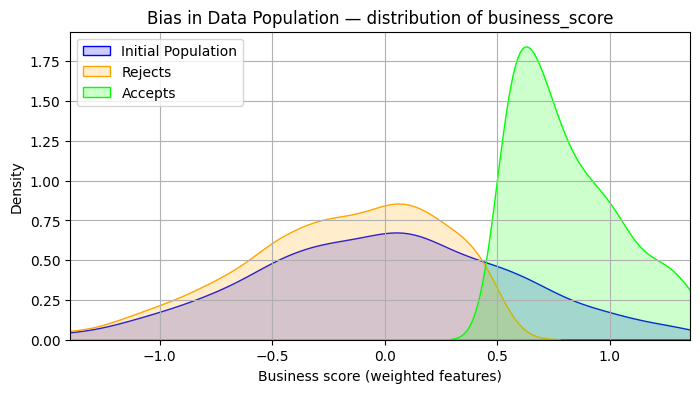

In [44]:
# 2) KDE plot on business_score
plt.figure(figsize=(8,4))
sns.kdeplot(init_population['business_score'], fill=True, color='blue', label='Initial Population', alpha=0.2)
sns.kdeplot(init_rejects['business_score'], fill=True, color='orange', label='Rejects', alpha=0.2)
sns.kdeplot(init_accepts['business_score'], fill=True, color='lime', label='Accepts', alpha=0.2)
plt.xlabel('Business score (weighted features)')
plt.title('Bias in Data Population — distribution of business_score')
plt.legend()
plt.grid(True)
plt.xlim(init_population['business_score'].quantile(0.01), init_population['business_score'].quantile(0.99))
plt.show()

In [45]:
# 3) Quick numeric diagnostics
print("Counts — initial / accepts / rejects:", len(init_population), len(init_accepts), len(init_rejects))
print("Mean business_score — initial / accepts / rejects:",
      init_population['business_score'].mean().round(3),
      init_accepts['business_score'].mean().round(3),
      init_rejects['business_score'].mean().round(3))

# Acceptance rate by true label (use numeric BAD column if available)
if 'BAD' in init_population.columns:
    # ensure numeric 0/1 for BAD for the diagnostics only
    try:
        bad_full = pd.to_numeric(init_population['BAD'], errors='coerce')
    except Exception:
        bad_full = init_population['BAD'].map({'GOOD':0, 'BAD':1}).astype(float)

    accept_mask = init_population.index.isin(init_accepts.index)
    accept_rate_by_label = {}
    for lab in [0,1]:
        mask = (bad_full == lab)
        if mask.sum() > 0:
            accept_rate_by_label[lab] = accept_mask[mask].mean()
        else:
            accept_rate_by_label[lab] = np.nan
    print("Acceptance rate by TRUE label (0=GOOD,1=BAD):", accept_rate_by_label)


Counts — initial / accepts / rejects: 4000 800 3200
Mean business_score — initial / accepts / rejects: 0.0 0.839 -0.21
Acceptance rate by TRUE label (0=GOOD,1=BAD): {0: nan, 1: nan}


Compare means: a much higher mean for accepts vs full population confirms the shift quantitatively.

In [46]:
# 4) Acceptance fraction and BAD prevalence by score decile (shows how acceptance changes with score)
df_tmp = init_population[['business_score']].copy()
df_tmp['accept'] = df_tmp.index.isin(init_accepts.index).astype(int)
if 'BAD' in init_population.columns:
    df_tmp['BAD_true'] = bad_full
else:
    df_tmp['BAD_true'] = np.nan

df_tmp['decile'] = pd.qcut(df_tmp['business_score'], 10, labels=False, duplicates='drop')
decile_stats = df_tmp.groupby('decile').agg(
    n = ('accept','size'),
    accept_rate = ('accept','mean'),
    bad_rate = ('BAD_true','mean')
).sort_index(ascending=False)  # highest score first
print("\nDecile stats (highest score decile at top):")
display(decile_stats.head(10))


Decile stats (highest score decile at top):


,n,accept_rate,bad_rate
decile,,,
9,400,1.0,NaN
8,400,1.0,NaN
7,400,0.0,NaN
6,400,0.0,NaN
5,400,0.0,NaN
4,400,0.0,NaN
3,400,0.0,NaN
2,400,0.0,NaN
1,400,0.0,NaN


In [47]:
A = init_accepts[features].astype(float).values
B = init_rejects[features].astype(float).values

# subsample if groups are large (speeds up MMD / permutation)
max_n = 1000
rng = np.random.RandomState(0)
if A.shape[0] > max_n:
    idx = rng.choice(A.shape[0], max_n, replace=False); A = A[idx]
if B.shape[0] > max_n:
    idx = rng.choice(B.shape[0], max_n, replace=False); B = B[idx]

pooled = np.vstack([A, B])
scaler = StandardScaler().fit(pooled)
A_s = scaler.transform(A)
B_s = scaler.transform(B)

#compute MMD^2 and gamma (unbiased estimator)
mmd2, gamma = mmd_rbf_unbiased(A_s, B_s)
print(f"MMD^2 (Accept vs Reject) = {mmd2:.6e}, gamma = {gamma:.6e}")

# permutation test (gives p-value)
mmd_obs, gamma, p_value = mmd_permutation_test(A_s, B_s, n_permutations=300, gamma=gamma, seed=0)
print(f"Permutation test p-value = {p_value:.4f}")



MMD^2 (Accept vs Reject) = 2.067781e-01, gamma = 1.143249e-01
Permutation test p-value = 0.0033


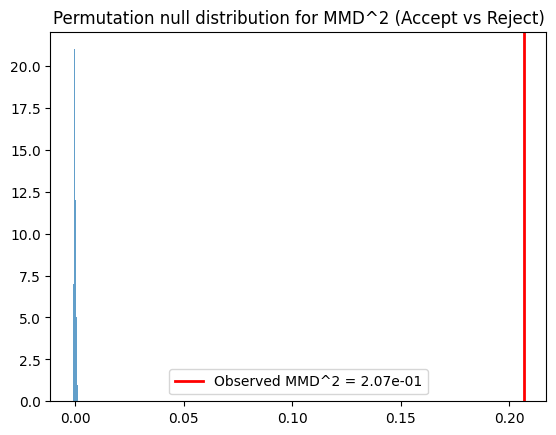

Interpretation:
- MMD^2 > 0 indicates multivariate difference (RBF kernel).
- Small p-value (e.g., < 0.05) means Accept and Reject are unlikely from same distribution under this kernel.
- Compare this MMD^2 to other scenarios (different generator params) to assess effect size.


In [49]:
# 6) compute permutation stats locally for plotting (useful to visualize null distribution)
# (mmd_permutation_test does not return perm_stats; compute them here if you want the histogram)

rng = np.random.RandomState(0)
Z = np.vstack([A_s, B_s])
n = A_s.shape[0]; m = B_s.shape[0]
labels = np.array([0]*n + [1]*m)
perm_stats = []
n_perm = 300
for i in range(n_perm):
    rng.shuffle(labels)
    Xp = Z[labels==0]
    Yp = Z[labels==1]
    # if shuffle changed sizes (rare), sample to original sizes
    if Xp.shape[0] != n:
        idx0 = np.where(labels==0)[0][:n]; idx1 = np.where(labels==1)[0][:m]
        Xp = Z[idx0]; Yp = Z[idx1]
    stat, _ = mmd_rbf_unbiased(Xp, Yp, gamma=gamma)
    perm_stats.append(stat)
perm_stats = np.array(perm_stats)

# 7) plot observed vs permuted (requires matplotlib)
import matplotlib.pyplot as plt
plt.hist(perm_stats, bins=40, alpha=0.7)
plt.axvline(mmd_obs, color='r', linewidth=2, label=f'Observed MMD^2 = {mmd_obs:.2e}')
plt.legend()
plt.title('Permutation null distribution for MMD^2 (Accept vs Reject)')
plt.show()

# 8) Quick interpretation helper
print("Interpretation:")
print("- MMD^2 > 0 indicates multivariate difference (RBF kernel).")
print("- Small p-value (e.g., < 0.05) means Accept and Reject are unlikely from same distribution under this kernel.")
print("- Compare this MMD^2 to other scenarios (different generator params) to assess effect size.")

In [50]:
X_train = init_accepts[features].astype(float).values
y_train = init_accepts['BAD'].map({'GOOD':0,'BAD':1}).astype(int).values
X_hold  = holdout.data[features].astype(float).values

probs_hold, tabpfn_model = train_tabpfn(X_train, y_train, X_hold, timeout_minutes=30, seed=42, verbose=1)

                                       

Training TabPFN on 800 samples, evaluating on 8000 samples.


In [51]:
# shapes and NaNs
print("X_train shape:", X_train.shape, "X_hold shape:", X_hold.shape, "y_train shape:", y_train.shape)
print("Any NaN in X_train:", np.isnan(X_train).any(), "Any NaN in X_hold:", np.isnan(X_hold).any())
print("y_train unique:", np.unique(y_train))

X_train shape: (800, 5) X_hold shape: (8000, 5) y_train shape: (800,)
Any NaN in X_train: False Any NaN in X_hold: False
y_train unique: [0 1]


Holdout prevalence: 0.80095
Baseline Brier (always predict p0): 0.15942909749999998


Holdout prevalence: 0.804
Baseline Brier (always predict p0): 0.15758399999999997
Holdout AUC: 0.7909837967369784 Brier: 0.12788941197524872


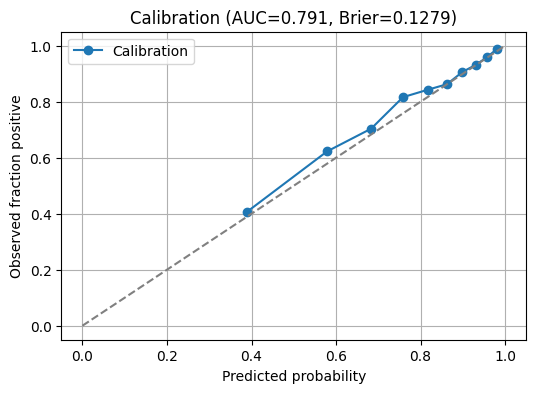

In [52]:
# probs_hold returned from train_tabpfn
y_hold = holdout.data['BAD'].map({'GOOD':0,'BAD':1}).astype(int).values

p0 = y_hold.mean()                     # holdout prevalence
brier_baseline = p0*(1-p0)**2 + (1-p0)*(p0**2)
print("Holdout prevalence:", p0)
print("Baseline Brier (always predict p0):", brier_baseline) 

auc = roc_auc_score(y_hold, probs_hold)
brier = brier_score_loss(y_hold, probs_hold)
print("Holdout AUC:", auc, "Brier:", brier)

# calibration plot
prob_true, prob_pred = calibration_curve(y_hold, probs_hold, n_bins=10, strategy='quantile')
plt.figure(figsize=(6,4))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel('Predicted probability')
plt.ylabel('Observed fraction positive')
plt.title(f'Calibration (AUC={auc:.3f}, Brier={brier:.4f})')
plt.grid(True); plt.legend(); plt.show()

model reduces mean squared probability error by ~0.0298 absolute (0.159 -0.129)-≈18.7% relative improvement vs baseline. Predicted probabilities are substantially more informative than the naive baseline.

In [38]:
# using your MMD_test functions (ensure MMD_test imported)

A = X_train
B = X_hold
pooled = np.vstack([A, B])
scaler = StandardScaler().fit(pooled)
A_s = scaler.transform(A)
B_s = scaler.transform(B)
mmd2, gamma = mmd_rbf_unbiased(A_s, B_s)
_, _, pval = mmd_permutation_test(A_s, B_s, n_permutations=300, gamma=gamma, seed=0)
print("MMD^2 (train vs holdout):", mmd2, "pval:", pval)


pooled = np.vstack([A, B])
scaler = StandardScaler().fit(pooled)
A_s = scaler.transform(A)
B_s = scaler.transform(B)


MMD^2 (train vs holdout): 0.13863358844639617 pval: 0.0033222591362126247


MMD^2 between GOOD and BAD is 0.0027 with a permutation p-value ≈ 0.013
MMD^2 (Accept vs Reject) = 1.122887e-01, gamma = 5.334816e-02
Permutation test p-value = 0.0033
MMD^2 (train vs holdout): 0.14009461809193424 pval: 0.0033222591362126247

TabPFN model trained on accepted cases achieves an AUC ≈ 0.79 on the large holdout, which is a reasonable discrimination level. The Brier score (≈0.13) is better than the naive baseline (≈0.16 for predicting prevalence 0.8), so predicted probabilities are informative. However, given selection bias (high MMD between accept and holdout)